In [ ]:
!pip install gdown
!pip install -q transformers torch sentencepiece huggingface_hub underthesea

In [ ]:
import os
import re
import math
import random
import string
import warnings

import gdown
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization,
    SimpleRNN,
    LSTM,
    Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from underthesea import text_normalize
from tqdm import tqdm

warnings.filterwarnings('ignore')

2026-05-14 07:55:03.052784: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778745303.451994      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778745303.565463      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778745304.553514      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778745304.553551      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778745304.553553      23 computation_placer.cc:177] computation placer alr

In [3]:
# Cài đặt wrapper Python cho VnCoreNLP.
!pip install vncorenlp

# Tải xuống VnCoreNLP và thành phần phân đoạn từ (RDRSegmenter).
!mkdir -p vncorenlp/models/wordsegmenter
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.1.1.jar
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/vi-vocab
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/wordsegmenter.rdr
!mv VnCoreNLP-1.1.1.jar vncorenlp/
!mv vi-vocab vncorenlp/models/wordsegmenter/
!mv wordsegmenter.rdr vncorenlp/models/wordsegmenter/

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 25.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for vncorenlp: filename=vncorenlp-1.0.3-py3-none-any.whl size=2645933 sha256=14c3f7417b440cbfd286cde86bfe7a61385a8079c22334f659c424c07585962e
  Stored in directory: /root/.cache/pip/wheels/6f/19/20/ec7083125fd06db1a19d0d3ca18806ecf4e8ed1464713b4efa
Successfully built vncorenlp
--2026-05-14 07:56:03--  https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.1.1.jar
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27412575 (26M) [application/octet-stream]
Saving to: ‘VnCoreNLP-1.1.1.jar’

VnCoreNLP-1.1.1.jar 100%[===================>]  26.14M  --.-KB/s    in 0.1s    

2026-05-14 07:56:04 (178 MB/s) - ‘VnCoreNLP

In [4]:
from vncorenlp import VnCoreNLP
# Khởi tạo RDRSegmenter từ VnCoreNLP để phân đoạn từ tiếng Việt.
rdrsegmenter = VnCoreNLP(
    "vncorenlp/VnCoreNLP-1.1.1.jar", 
    annotators="wseg", 
    max_heap_size='-Xmx500m')

text = "thầy nhiệt tình giảng dạy, gần gũi với sinh viên"

# Phân đoạn từ cho đoạn văn bản tiếng Việt.
word_segmented_text = rdrsegmenter.tokenize(text)
print(word_segmented_text)

[['thầy', 'nhiệt_tình', 'giảng_dạy', ',', 'gần_gũi', 'với', 'sinh_viên']]


In [5]:
# URL gốc trên Google Drive 
URLS = {
    "train": {
        "sentences": "https://drive.google.com/uc?id=1nzak5OkrheRV1ltOGCXkT671bmjODLhP",
        "sentiments": "https://drive.google.com/uc?id=1ye-gOZIBqXdKOoi_YxvpT6FeRNmViPPv",
        "topics": "https://drive.google.com/uc?id=14MuDtwMnNOcr4z_8KdpxprjbwaQ7lJ_C",
    },
    "validation": {
        "sentences": "https://drive.google.com/uc?id=1sMJSR3oRfPc3fe1gK-V3W5F24tov_517",
        "sentiments": "https://drive.google.com/uc?id=1GiY1AOp41dLXIIkgES4422AuDwmbUseL",
        "topics": "https://drive.google.com/uc?id=1DwLgDEaFWQe8mOd7EpF-xqMEbDLfdT-W",
    },
    "test": {
        "sentences": "https://drive.google.com/uc?id=1aNMOeZZbNwSRkjyCWAGtNCMa3YrshR-n",
        "sentiments": "https://drive.google.com/uc?id=1vkQS5gI0is4ACU58-AbWusnemw7KZNfO",
        "topics": "https://drive.google.com/uc?id=1_ArMpDguVsbUGl-xSMkTF_p5KpZrmpSB",
    },
}

TRAIN_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/train_final.csv"
VAL_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/val_final.csv"
TEST_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/test_final.csv"

# Tải và đọc từng split 
def load_split(name, urls):
    files = {}
    for k, url in urls.items():
        output = f"{name}_{k}.txt"
        gdown.download(url, output, quiet=True)
        files[k] = output

    # Đọc 3 file và gộp lại
    with open(files["sentences"], encoding="utf-8") as f:
        sentences = [line.strip() for line in f]
    with open(files["sentiments"], encoding="utf-8") as f:
        sentiments = [int(line.strip()) for line in f]
    with open(files["topics"], encoding="utf-8") as f:
        topics = [int(line.strip()) for line in f]

    return pd.DataFrame({
        "sentence": sentences,
        "sentiment": sentiments,
        "topic": topics
    })

# Tải từng tập
train_df = load_split("train", URLS["train"])
val_df   = load_split("val", URLS["validation"])
test_df  = load_split("test", URLS["test"])

def load_data_from_csv():
    try:
        # Load file đã cập nhật nhãn
        train_df = pd.read_csv(TRAIN_PATH)
        val_df = pd.read_csv(VAL_PATH)
        test_df1 = pd.read_csv(TEST_PATH)
        
        print("--- Thông tin dữ liệu đã load ---")
        print(f"Tập Train: {len(train_df)} mẫu")
        print(f"Tập Val  : {len(val_df)} mẫu")
        print(f"Tập Test  : {len(test_df1)} mẫu")
        
        
        # return train_df, val_df, test_df1
        return test_df1
    
    except FileNotFoundError as e:
        print(f"Lỗi: Không tìm thấy file. Hãy chắc chắn bạn đã chạy bước xuất CSV trước đó. \nChi tiết: {e}")
        return None, None

# 2. Thực thi load dữ liệu
# train_df, val_df, test_df1 = load_data_from_csv()
test_df1 = load_data_from_csv()

--- Thông tin dữ liệu đã load ---
Tập Train: 11426 mẫu
Tập Val  : 1583 mẫu
Tập Test  : 3166 mẫu


# Preprocessing

In [ ]:
def load_external_teencode(file_path):
    """Hàm đọc file teencode.txt từ Kaggle và chuyển thành Dictionary"""
    external_dict = {}
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                # Thông thường file teencode.txt trên Kaggle phân tách bằng dấu Tab (\t)
                # Nếu file dùng định dạng khác (như dấu phẩy), hãy đổi split('\t') thành split(',')
                parts = line.strip().split('\t') 
                if len(parts) >= 2:
                    teencode = parts[0].strip().lower()
                    standard = parts[1].strip().lower()
                    external_dict[teencode] = standard
        print(f"Đã tải thành công {len(external_dict)} từ teencode từ file Kaggle.")
    except Exception as e:
        print(f"Lỗi khi đọc file teencode: {e}")
    return external_dict

# Từ điển giải mã Emoticon đặc thù của dữ liệu UIT-VSFC
UIT_VSFC_EMOTICON_DICT = {
    "colonsmilesmile": "rất vui", "colondoublesurprise": "rất bất ngờ",
    "colonbigsmile": "cười to", "colonsadcolon": "rất buồn",
    "colonsmalsmile": "mỉm cười", "colonsmile": "vui vẻ",
    "colonlove": "yêu thích", "colonsad": "buồn bã",
    "colonhihi": "vui vẻ", "coloncontemn": "chê bai",
    "coloncolon": "bối rối" 
}

# Từ điển tự định nghĩa (Mang tính cục bộ của môi trường đại học)
CUSTOM_TEENCODE_DICT = {
    "ko": "không", "k": "không", "kh": "không", "khg": "không", "kg": "không",
    "dc": "được", "đc": "được", "duoc": "được",
    "sv": "sinh viên", "gv": "giảng viên", "thầy cô": "giảng viên",
    "vs": "với", "r": "rồi", "ah": "à", "nhìu": "nhiều",
    "bt": "bình thường", "tot": "tốt", "thik": "thích", 
    "ntn": "như thế nào", "nv": "nhân viên", "cs vc": "cơ sở vật chất",
    "csvc": "cơ sở vật chất", "wifi": "mạng", "phong": "phòng", "vkl": "vô cùng",
    "vl": "vô cùng", "vcl": "vô cùng", "đm": "chửi thề", "vãi": "rất"
}

# Tiến hành hợp nhất 2 từ điển
KAGGLE_FILE_PATH = '/kaggle/input/datasets/taiduong1/vietnamese-teencode/teencode.txt'

# Bước 1: Load file gốc
FINAL_TEENCODE_DICT = load_external_teencode(KAGGLE_FILE_PATH)

# Bước 2: Dùng lệnh .update() để hợp nhất. 
# Từ điển CUSTOM sẽ ghi đè lên EXTERNAL nếu có các key trùng lặp.
FINAL_TEENCODE_DICT.update(CUSTOM_TEENCODE_DICT)

print(f"Tổng số từ khóa teencode hiện có trong bộ lọc: {len(FINAL_TEENCODE_DICT)}")

def clean_vietnamese_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Dùng thư viện ngoài để chuẩn hóa Unicode
    text = text_normalize(text).lower()
    
    # 2. Giải mã các chuỗi emoticon đặc thù
    for encoded_emo, meaning in UIT_VSFC_EMOTICON_DICT.items():
        text = re.sub(r'\b' + re.escape(encoded_emo) + r'\b', f" {meaning} ", text)
        
    # 3. Chuẩn hóa Teencode bằng TỪ ĐIỂN ĐÃ HỢP NHẤT
    for word, true_word in FINAL_TEENCODE_DICT.items():
        text = re.sub(r'\b' + re.escape(word) + r'\b', f" {true_word} ", text)
        
    # 4. Loại bỏ dấu câu (Punctuation)
    punctuations = string.punctuation + '”’“‘…—'
    for p in punctuations:
        text = text.replace(p, ' ')
        
    # 5. Loại bỏ kí tự rác (Chỉ giữ chữ cái tiếng Việt, số, khoảng trắng)
    text = re.sub(r'[^\s\wáàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵđ]', ' ', text)
    
    # 6. Chuẩn hóa khoảng trắng liên tiếp
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

train_df['cleaned_text'] = train_df['sentence'].apply(clean_vietnamese_text)
val_df['cleaned_text'] = val_df['sentence'].apply(clean_vietnamese_text)
test_df['cleaned_text'] = test_df['sentence'].apply(clean_vietnamese_text)
test_df1['cleaned_text'] = test_df1['sentence'].apply(clean_vietnamese_text)

Đã tải thành công 389 từ teencode từ file Kaggle.
Tổng số từ khóa teencode hiện có trong bộ lọc: 406


# Segment toàn bộ dataset

In [ ]:
def word_segment(text):
    if not isinstance(text, str):
        return ""
    try:
        tokens = rdrsegmenter.tokenize(text)
        return " ".join([w for sent in tokens for w in sent])
    except Exception:
        return text

train_df['sentence_seg'] = train_df['sentence'].apply(word_segment)
val_df['sentence_seg'] = val_df['sentence'].apply(word_segment)
test_df['sentence_seg'] = test_df['sentence'].apply(word_segment)
test_df1['sentence_seg'] = test_df1['sentence'].apply(word_segment)

train_df.head()

,sentence,sentiment,topic,sentence_seg
0,slide giáo trình đầy đủ .,2,1,slide giáo_trình đầy_đủ .
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0,"nhiệt_tình giảng_dạy , gần_gũi với sinh_viên ."
2,đi học đầy đủ full điểm chuyên cần .,0,1,đi học đầy_đủ full điểm chuyên_cần .
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,chưa áp_dụng công_nghệ_thông_tin và các thiết_...
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0,"thầy giảng bài hay , có nhiều bài_tập ví_dụ ng..."


# B0 baseline singletask 

In [ ]:
# config
MODEL_NAME   = "vinai/phobert-base"
MAX_LEN      = 128
BATCH_SIZE   = 32
LR           = 2e-5
EPOCHS       = 10
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_SENTIMENT = 3   # Negative=0, Neutral=1, Positive=2
NUM_TOPIC     = 4   # Lecturer=0, Training=1, Facility=2, Others=3

SENT_NAMES  = ["Negative", "Neutral", "Positive"]
TOPIC_NAMES = ["Lecturer", "Training", "Facility", "Others"]

print(f"Device: {DEVICE}")

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

# tokenizer 
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# DATASET CLASS
class FeedbackDataset(Dataset):
    def __init__(self, sentences, sentiments, topics, tokenizer, max_len):
        self.sentences  = sentences
        self.sentiments = sentiments
        self.topics     = topics
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.sentences[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "sentiment":      torch.tensor(self.sentiments[idx], dtype=torch.long),
            "topic":          torch.tensor(self.topics[idx],     dtype=torch.long),
        }


def make_loader(df, shuffle=True):
    ds = FeedbackDataset(
        # df["sentence"].tolist(),
        df["sentence_seg"].tolist(), 
        df["sentiment"].tolist(),
        df["topic"].tolist(),
        tokenizer, MAX_LEN
    )
    return DataLoader(ds, batch_size=BATCH_SIZE,
                      shuffle=shuffle, num_workers=2, pin_memory=True)

train_loader = make_loader(train_df, shuffle=True)
val_loader   = make_loader(val_df,   shuffle=False)
test_loader  = make_loader(test_df,  shuffle=False)
test_loader1  = make_loader(test_df1,  shuffle=False)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)} | Test relabled: {len(test_df1)}")

# CLASS WEIGHTS 
def compute_class_weights(labels, num_classes):
    """Inverse frequency weighting."""
    counts = np.bincount(labels, minlength=num_classes).astype(float)
    weights = 1.0 / (counts + 1e-6)
    weights = weights / weights.sum() * num_classes   # normalize
    return torch.tensor(weights, dtype=torch.float32)

def compute_focal_alpha(labels: np.ndarray, num_classes: int) -> torch.Tensor:
    """
    Alpha cho Focal Loss.
    Normalize về sum = 1 (không nhân num_classes).
    """
    counts = np.bincount(labels, minlength=num_classes).astype(float)
    alpha  = 1.0 / (counts + 1e-8)
    alpha  = alpha / alpha.sum()
    return torch.tensor(alpha, dtype=torch.float32)

sent_weights  = compute_class_weights(train_df["sentiment"].values, NUM_SENTIMENT)
topic_weights = compute_class_weights(train_df["topic"].values,     NUM_TOPIC)
sent_focal_alpha  = compute_focal_alpha(train_df["sentiment"].values, NUM_SENTIMENT)
topic_focal_alpha = compute_focal_alpha(train_df["topic"].values,     NUM_TOPIC)
print("Sentiment weights:", sent_weights.round(decimals=3))
print("Topic weights    :", topic_weights.round(decimals=3))
print("Focal alpha  (sentiment):", sent_focal_alpha.numpy().round(4))
print("Focal alpha  (topic)    :", topic_focal_alpha.numpy().round(4))

def predict_test(model, loader, task):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids, mask = batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE)
            logits = model(ids, mask)
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(batch[task].tolist())
    return f1_score(all_labels, all_preds, average="macro"), all_labels, all_preds

def evaluate_and_plot(model, loader, task, target_names, title="Confusion Matrix"):
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            logits = model(ids, mask)
            y_pred.extend(logits.argmax(-1).cpu().tolist())
            y_true.extend(batch[task].tolist())
            
    print(f"\n=== {title.upper()} ===")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()
    
    return classification_report(y_true, y_pred, target_names=target_names, digits=4, output_dict=True)

def plot_training_history(history_df, title="Training History"):
    if history_df is None or history_df.empty:
        print(f"Cannot plot '{title}': DataFrame is empty.")
        return
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Biểu đồ 1: Train Loss vs Val Loss
    ax1.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', marker='o', color='tab:red')
    ax1.plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', marker='s', color='tab:orange')
    ax1.set_title('Mức độ lỗi (Loss) qua các Epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Biểu đồ 2: Train F1 vs Val F1
    ax2.plot(history_df['epoch'], history_df['train_f1'], label='Train Macro F1', marker='o', color='tab:blue')
    ax2.plot(history_df['epoch'], history_df['val_f1'], label='Val Macro F1', marker='s', color='tab:green')
    ax2.set_title('Độ chính xác (Macro F1) qua các Epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Macro F1 Score')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Chẩn đoán trên tập val trước khi lưu test
def diagnose_validation_single_task(model, val_loader, model_name, task):
    """In Classification Report trực tiếp trên tập Validation để chẩn đoán lớp thiểu số cho Single-Task"""
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in val_loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            
            # Mô hình single-task chỉ trả về 1 logit
            logits = model(ids, mask)
            
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(batch[task].tolist())

    print(f"\nChẩn đoán validation === {model_name} ({task.upper()}) ===")
    
    if task == "sentiment":
        target_names = ["Negative", "Neutral", "Positive"]
    elif task == "topic":
        target_names = ["Lecturer", "Training", "Facility", "Others"]
    else:
        target_names = None
        
    print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))

Device: cuda


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 11426 | Val: 1583 | Test: 3166 | Test relabled: 3166
Sentiment weights: tensor([0.2210, 2.5700, 0.2090])
Topic weights    : tensor([0.1120, 0.4160, 1.8420, 1.6290])
Focal alpha  (sentiment): [0.0737 0.8568 0.0695]
Focal alpha  (topic)    : [0.028  0.104  0.4606 0.4073]


In [ ]:
# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.alpha = alpha   # tensor shape [num_classes]
        self.gamma = gamma
        
    def forward(self, logits, targets):
        # Cross-entropy từng sample, không reduction
        ce = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)                      # xác suất đúng
        alpha_t = self.alpha.to(logits.device)[targets]
        fl = alpha_t * (1 - pt) ** self.gamma * ce
        return fl.mean()


class ClassSpecificAsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg_list, gamma_pos_list, clip=0.05, eps=1e-8):
        super(ClassSpecificAsymmetricLoss, self).__init__()
        self.register_buffer('gamma_neg', torch.tensor(gamma_neg_list, dtype=torch.float32))
        self.register_buffer('gamma_pos', torch.tensor(gamma_pos_list, dtype=torch.float32))
        self.clip = clip
        self.eps = eps

    def forward(self, x, y):
        num_classes = x.size(1)
        y_onehot = F.one_hot(y, num_classes=num_classes).float()
        
        # Dùng sigmoid thay vì softmax
        xs_pos = torch.sigmoid(x)
        xs_neg = 1.0 - xs_pos
        
        # Probability shifting
        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1)

        # Cross Entropy cơ bản
        los_pos = y_onehot * torch.log(xs_pos.clamp(min=self.eps))
        los_neg = (1 - y_onehot) * torch.log(xs_neg.clamp(min=self.eps))
         # Mở rộng ma trận Gamma
        gamma_pos_t = self.gamma_pos.unsqueeze(0).expand_as(x)
        gamma_neg_t = self.gamma_neg.unsqueeze(0).expand_as(x)

        # Tính xác suất tổng hợp và Gamma tương ứng
        pt = (xs_pos * y_onehot) + (xs_neg * (1 - y_onehot))
        one_sided_gamma = (gamma_pos_t * y_onehot) + (gamma_neg_t * (1 - y_onehot))
        
        # Trọng số Asymmetric
        one_sided_w = torch.pow(1 - pt, one_sided_gamma)
        
        loss = -(los_pos + los_neg) * one_sided_w
        return loss.sum(dim=-1).mean()


B0 (CE): Single Task - Standard Cross Entropy


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Epoch 01 | Train Loss: 0.4582 | Val Loss: 0.2065 | Train F1: 0.5963 | Val F1: 0.8268
New best (Val F1: 0.8268)
Epoch 02 | Train Loss: 0.1844 | Val Loss: 0.1976 | Train F1: 0.8251 | Val F1: 0.8039
Không cải thiện 1/3
Epoch 03 | Train Loss: 0.1359 | Val Loss: 0.2082 | Train F1: 0.8806 | Val F1: 0.8230
Không cải thiện 2/3
Epoch 04 | Train Loss: 0.1023 | Val Loss: 0.2128 | Train F1: 0.9093 | Val F1: 0.8570
New best (Val F1: 0.8570)
Epoch 05 | Train Loss: 0.0772 | Val Loss: 0.2336 | Train F1: 0.9436 | Val F1: 0.8621
New best (Val F1: 0.8621)
Epoch 06 | Train Loss: 0.0629 | Val Loss: 0.2681 | Train F1: 0.9613 | Val F1: 0.8560
Không cải thiện 1/3
Epoch 07 | Train Loss: 0.0500 | Val Loss: 0.2701 | Train F1: 0.9674 | Val F1: 0.8575
Không cải thiện 2/3
Epoch 08 | Train Loss: 0.0392 | Val Loss: 0.2841 | Train F1: 0.9767 | Val F1: 0.8455
Không cải thiện 3/3
Early stopping tại epoch 8!

Best validation sentiment Macro F1: 0.8621


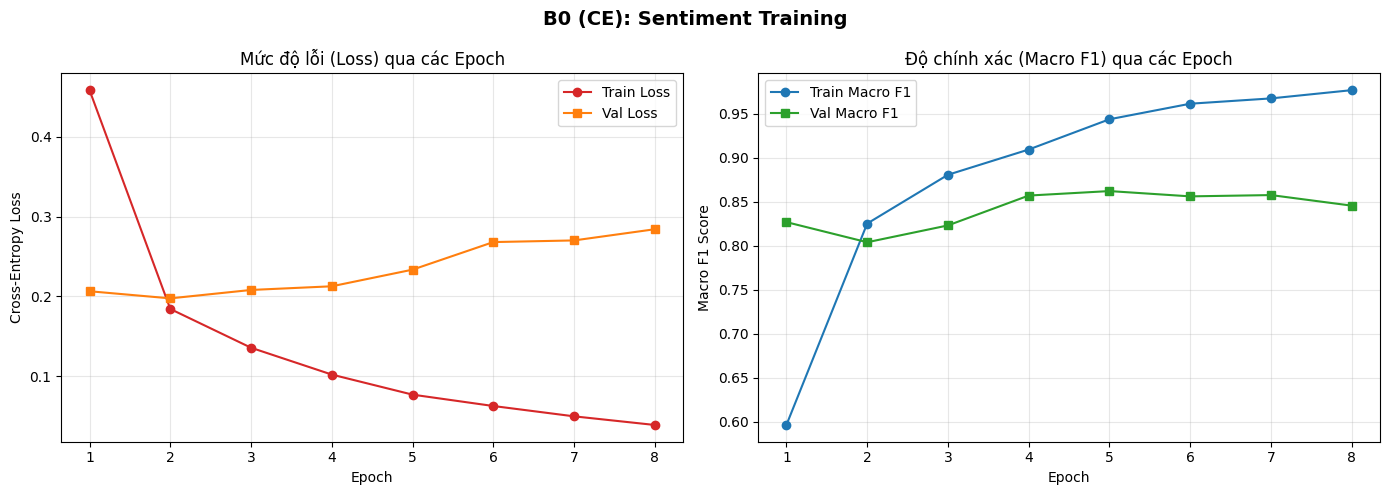


Chẩn đoán validation === B0_CE_Sent (SENTIMENT) ===
              precision    recall  f1-score   support

    Negative     0.9552    0.9674    0.9612       705
     Neutral     0.6714    0.6438    0.6573        73
    Positive     0.9712    0.9640    0.9676       805

    accuracy                         0.9507      1583
   macro avg     0.8659    0.8584    0.8621      1583
weighted avg     0.9502    0.9507    0.9505      1583


=== B0 (CE) SENTIMENT - OLD TEST ===
              precision    recall  f1-score   support

    Negative     0.9493    0.9702    0.9596      1409
     Neutral     0.6753    0.6228    0.6480       167
    Positive     0.9618    0.9509    0.9564      1590

    accuracy                         0.9422      3166
   macro avg     0.8622    0.8480    0.8547      3166
weighted avg     0.9411    0.9422    0.9415      3166



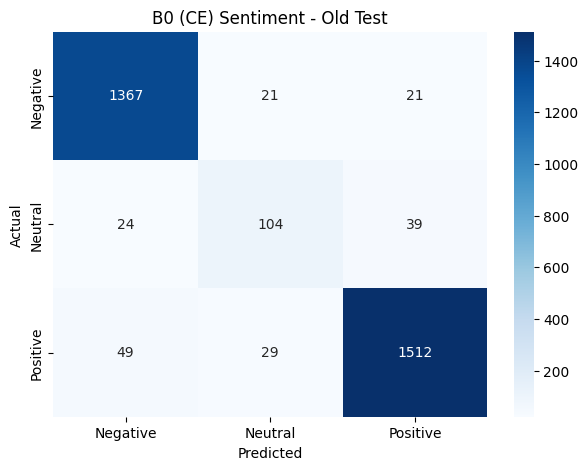


=== B0 (CE) SENTIMENT - NEW TEST ===
              precision    recall  f1-score   support

    Negative     0.9576    0.9836    0.9704      1402
     Neutral     0.7143    0.6962    0.7051       158
    Positive     0.9847    0.9639    0.9742      1606

    accuracy                         0.9593      3166
   macro avg     0.8856    0.8812    0.8833      3166
weighted avg     0.9592    0.9593    0.9591      3166



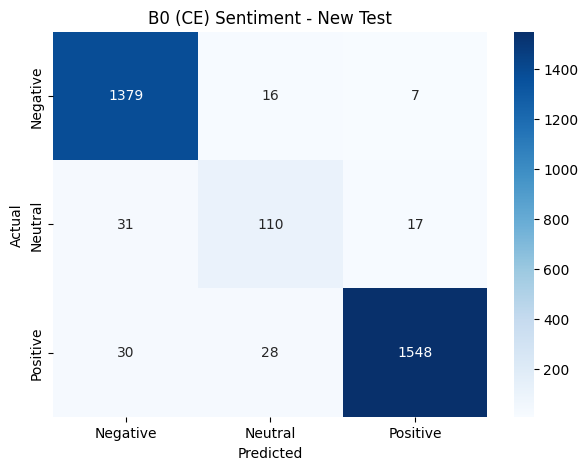

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.6389 | Val Loss: 0.3143 | Train F1: 0.5067 | Val F1: 0.7874
New best (Val F1: 0.7874)
Epoch 02 | Train Loss: 0.3052 | Val Loss: 0.2920 | Train F1: 0.7916 | Val F1: 0.8053
New best (Val F1: 0.8053)
Epoch 03 | Train Loss: 0.2444 | Val Loss: 0.3293 | Train F1: 0.8416 | Val F1: 0.8092
New best (Val F1: 0.8092)
Epoch 04 | Train Loss: 0.1983 | Val Loss: 0.3459 | Train F1: 0.8807 | Val F1: 0.8151
New best (Val F1: 0.8151)
Epoch 05 | Train Loss: 0.1580 | Val Loss: 0.3775 | Train F1: 0.9116 | Val F1: 0.8072
Không cải thiện 1/3
Epoch 06 | Train Loss: 0.1236 | Val Loss: 0.4234 | Train F1: 0.9325 | Val F1: 0.8124
Không cải thiện 2/3
Epoch 07 | Train Loss: 0.0981 | Val Loss: 0.4596 | Train F1: 0.9527 | Val F1: 0.8078
Không cải thiện 3/3
Early stopping tại epoch 7!

Best validation topic Macro F1: 0.8151


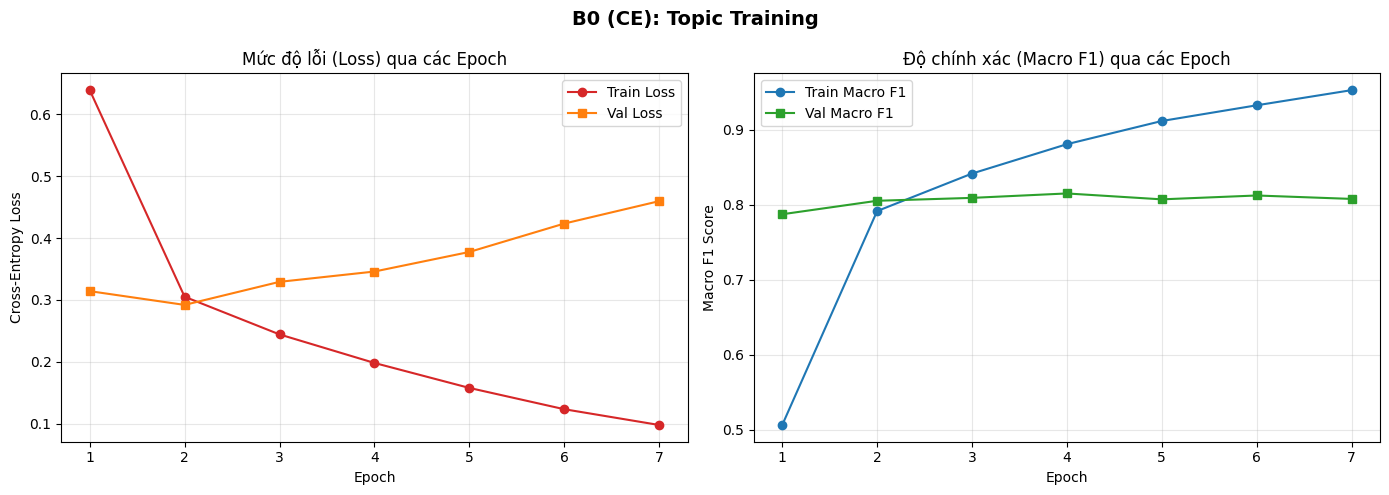


Chẩn đoán validation === B0_CE_Topic (TOPIC) ===
              precision    recall  f1-score   support

    Lecturer     0.9539    0.9340    0.9438      1151
    Training     0.7391    0.8914    0.8081       267
    Facility     0.9275    0.9143    0.9209        70
      Others     0.7231    0.4947    0.5875        95

    accuracy                         0.8996      1583
   macro avg     0.8359    0.8086    0.8151      1583
weighted avg     0.9026    0.8996    0.8985      1583


=== B0 (CE) TOPIC - OLD TEST ===
              precision    recall  f1-score   support

    Lecturer     0.9482    0.9201    0.9340      2290
    Training     0.7037    0.8304    0.7618       572
    Facility     0.9195    0.9448    0.9320       145
      Others     0.6333    0.4780    0.5448       159

    accuracy                         0.8828      3166
   macro avg     0.8012    0.7933    0.7931      3166
weighted avg     0.8869    0.8828    0.8832      3166



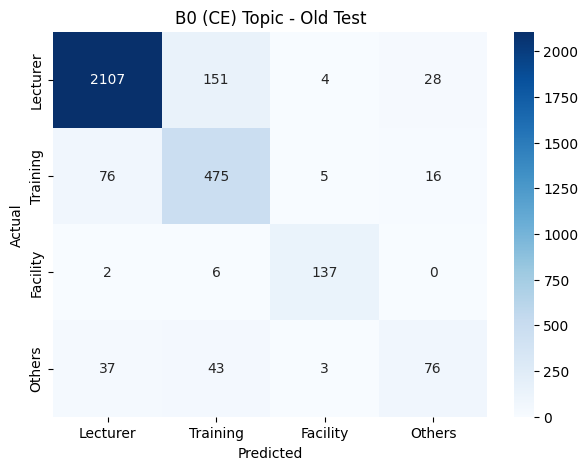


=== B0 (CE) TOPIC - NEW TEST ===
              precision    recall  f1-score   support

    Lecturer     0.9694    0.9394    0.9542      2293
    Training     0.7867    0.8985    0.8389       591
    Facility     0.9530    0.9726    0.9627       146
      Others     0.7167    0.6324    0.6719       136

    accuracy                         0.9201      3166
   macro avg     0.8564    0.8607    0.8569      3166
weighted avg     0.9237    0.9201    0.9209      3166



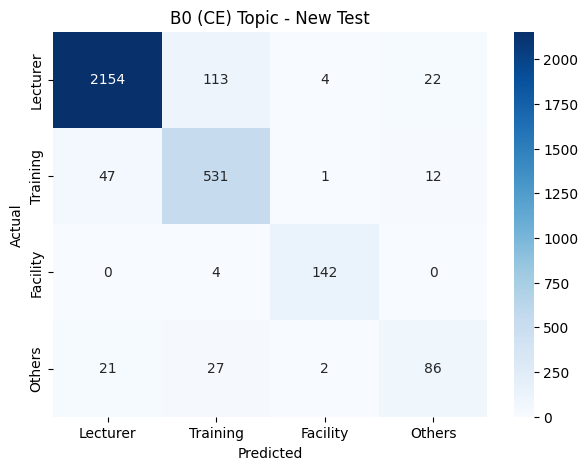


B0 (WCE): Single Task - Weighted Cross Entropy


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.7343 | Val Loss: 0.4867 | Train F1: 0.6412 | Val F1: 0.8142
New best (Val F1: 0.8142)
Epoch 02 | Train Loss: 0.3830 | Val Loss: 0.4498 | Train F1: 0.8176 | Val F1: 0.8480
New best (Val F1: 0.8480)
Epoch 03 | Train Loss: 0.2950 | Val Loss: 0.6857 | Train F1: 0.8765 | Val F1: 0.8561
New best (Val F1: 0.8561)
Epoch 04 | Train Loss: 0.1986 | Val Loss: 0.7304 | Train F1: 0.9220 | Val F1: 0.8614
New best (Val F1: 0.8614)
Epoch 05 | Train Loss: 0.1544 | Val Loss: 0.7532 | Train F1: 0.9432 | Val F1: 0.8641
New best (Val F1: 0.8641)
Epoch 06 | Train Loss: 0.1075 | Val Loss: 0.8706 | Train F1: 0.9621 | Val F1: 0.8657
New best (Val F1: 0.8657)
Epoch 07 | Train Loss: 0.0976 | Val Loss: 0.8817 | Train F1: 0.9740 | Val F1: 0.8614
Không cải thiện 1/3
Epoch 08 | Train Loss: 0.0591 | Val Loss: 1.0332 | Train F1: 0.9800 | Val F1: 0.8546
Không cải thiện 2/3
Epoch 09 | Train Loss: 0.0528 | Val Loss: 1.0657 | Train F1: 0.9817 | Val F1: 0.8545
Không cải thiện 3/3
Early stopping tại 

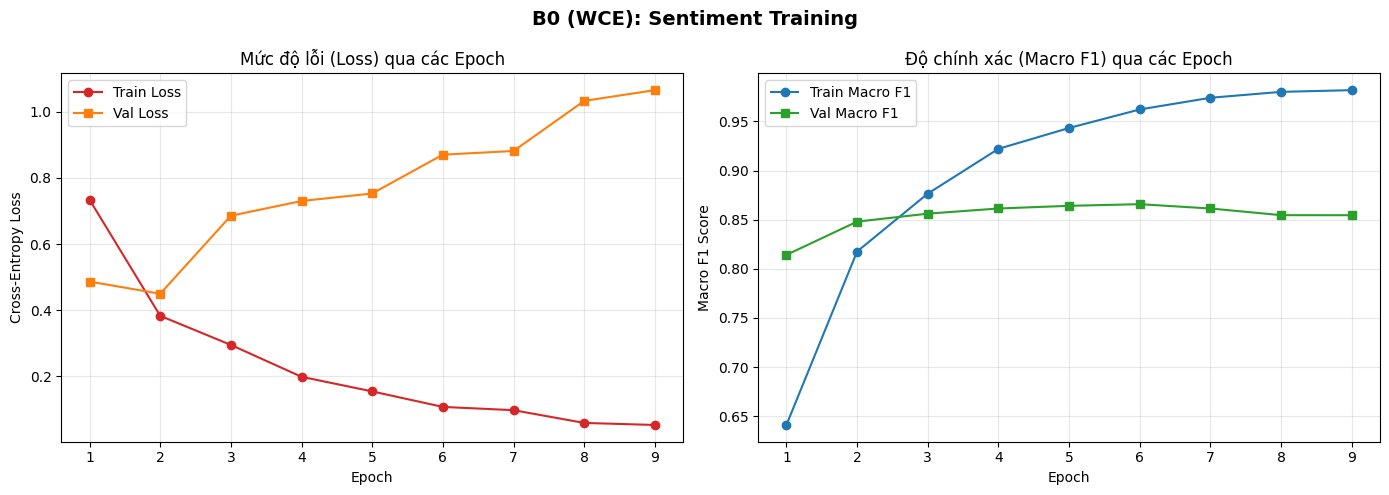


Chẩn đoán validation === B0_WCE_Sent (SENTIMENT) ===
              precision    recall  f1-score   support

    Negative     0.9554    0.9730    0.9642       705
     Neutral     0.7258    0.6164    0.6667        73
    Positive     0.9676    0.9652    0.9664       805

    accuracy                         0.9526      1583
   macro avg     0.8830    0.8516    0.8657      1583
weighted avg     0.9510    0.9526    0.9516      1583


=== B0 (WCE) SENTIMENT - OLD TEST ===
              precision    recall  f1-score   support

    Negative     0.9498    0.9666    0.9581      1409
     Neutral     0.7121    0.5629    0.6288       167
    Positive     0.9550    0.9610    0.9580      1590

    accuracy                         0.9425      3166
   macro avg     0.8723    0.8302    0.8483      3166
weighted avg     0.9399    0.9425    0.9407      3166



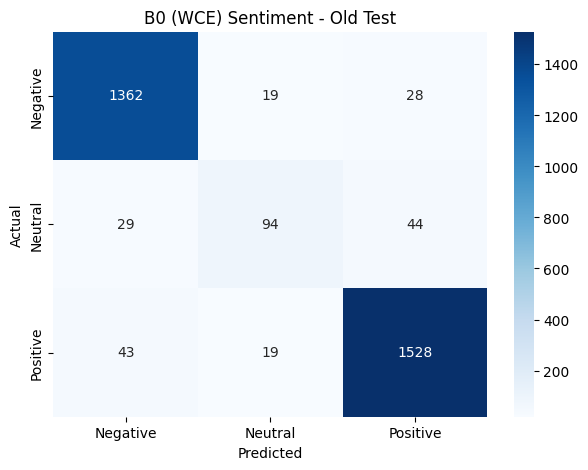


=== B0 (WCE) SENTIMENT - NEW TEST ===
              precision    recall  f1-score   support

    Negative     0.9589    0.9807    0.9697      1402
     Neutral     0.7273    0.6076    0.6621       158
    Positive     0.9756    0.9720    0.9738      1606

    accuracy                         0.9577      3166
   macro avg     0.8873    0.8534    0.8685      3166
weighted avg     0.9558    0.9577    0.9564      3166



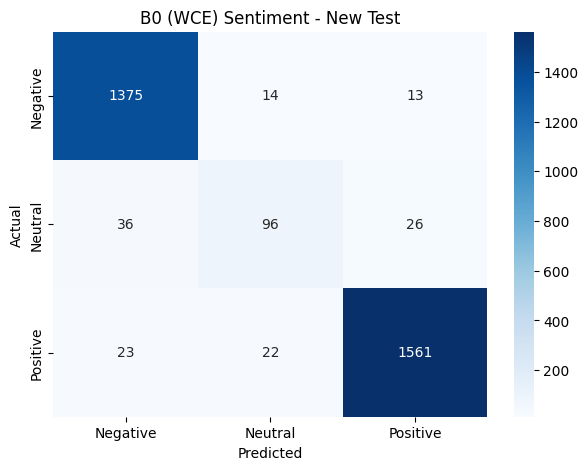

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.9522 | Val Loss: 0.4710 | Train F1: 0.5472 | Val F1: 0.7807
New best (Val F1: 0.7807)
Epoch 02 | Train Loss: 0.4691 | Val Loss: 0.6448 | Train F1: 0.7749 | Val F1: 0.7711
Không cải thiện 1/3
Epoch 03 | Train Loss: 0.3792 | Val Loss: 0.5403 | Train F1: 0.8246 | Val F1: 0.8108
New best (Val F1: 0.8108)
Epoch 04 | Train Loss: 0.3012 | Val Loss: 0.6434 | Train F1: 0.8646 | Val F1: 0.7914
Không cải thiện 1/3
Epoch 05 | Train Loss: 0.2251 | Val Loss: 0.8024 | Train F1: 0.8972 | Val F1: 0.8102
Không cải thiện 2/3
Epoch 06 | Train Loss: 0.1763 | Val Loss: 0.7899 | Train F1: 0.9257 | Val F1: 0.8020
Không cải thiện 3/3
Early stopping tại epoch 6!

Best validation topic Macro F1: 0.8108


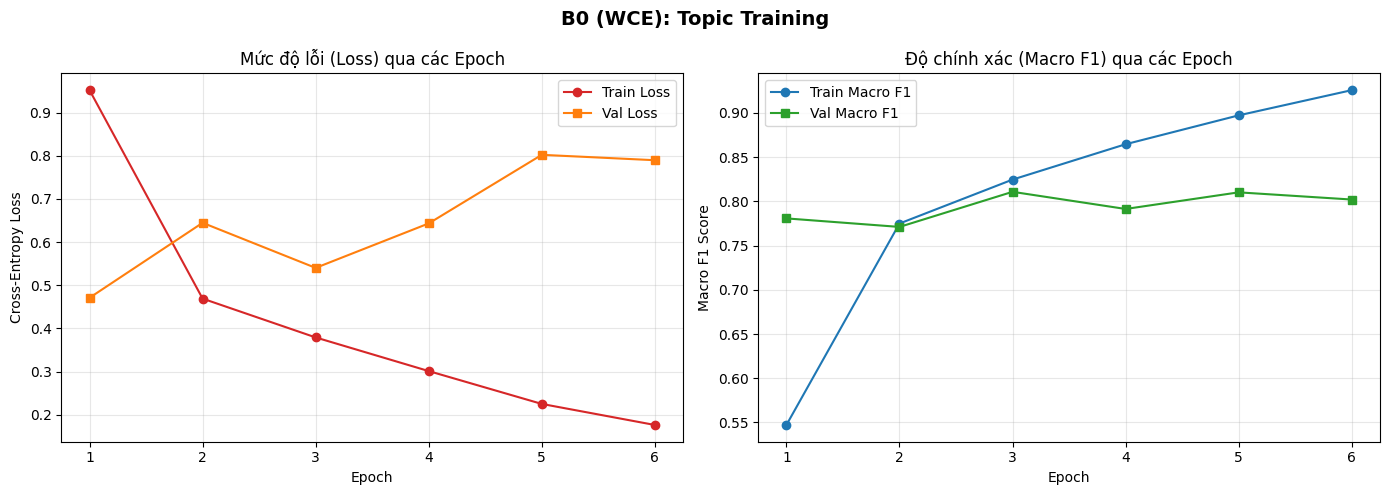


Chẩn đoán validation === B0_WCE_Topic (TOPIC) ===
              precision    recall  f1-score   support

    Lecturer     0.9545    0.9296    0.9419      1151
    Training     0.7909    0.7790    0.7849       267
    Facility     0.9178    0.9571    0.9371        70
      Others     0.5079    0.6737    0.5792        95

    accuracy                         0.8901      1583
   macro avg     0.7928    0.8349    0.8108      1583
weighted avg     0.8985    0.8901    0.8934      1583


=== B0 (WCE) TOPIC - OLD TEST ===
              precision    recall  f1-score   support

    Lecturer     0.9500    0.9205    0.9350      2290
    Training     0.7746    0.7692    0.7719       572
    Facility     0.9329    0.9586    0.9456       145
      Others     0.4609    0.6667    0.5450       159

    accuracy                         0.8822      3166
   macro avg     0.7796    0.8288    0.7994      3166
weighted avg     0.8930    0.8822    0.8864      3166



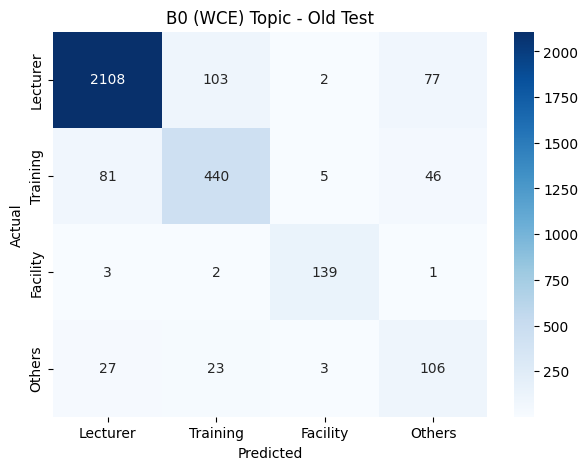


=== B0 (WCE) TOPIC - NEW TEST ===
              precision    recall  f1-score   support

    Lecturer     0.9730    0.9416    0.9570      2293
    Training     0.8662    0.8325    0.8490       591
    Facility     0.9597    0.9795    0.9695       146
      Others     0.4870    0.8235    0.6120       136

    accuracy                         0.9179      3166
   macro avg     0.8215    0.8943    0.8469      3166
weighted avg     0.9315    0.9179    0.9226      3166



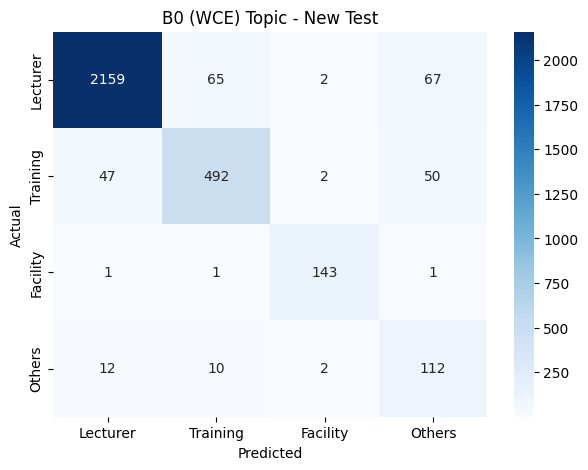


B0 (Focal): Single Task - Focal Loss


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.0312 | Val Loss: 0.0146 | Train F1: 0.5810 | Val F1: 0.7421
New best (Val F1: 0.7421)
Epoch 02 | Train Loss: 0.0131 | Val Loss: 0.0125 | Train F1: 0.7669 | Val F1: 0.8270
New best (Val F1: 0.8270)
Epoch 03 | Train Loss: 0.0082 | Val Loss: 0.0174 | Train F1: 0.8300 | Val F1: 0.8481
New best (Val F1: 0.8481)
Epoch 04 | Train Loss: 0.0056 | Val Loss: 0.0206 | Train F1: 0.8826 | Val F1: 0.8433
Không cải thiện 1/3
Epoch 05 | Train Loss: 0.0037 | Val Loss: 0.0411 | Train F1: 0.9088 | Val F1: 0.8721
New best (Val F1: 0.8721)
Epoch 06 | Train Loss: 0.0026 | Val Loss: 0.0443 | Train F1: 0.9451 | Val F1: 0.8580
Không cải thiện 1/3
Epoch 07 | Train Loss: 0.0024 | Val Loss: 0.0485 | Train F1: 0.9525 | Val F1: 0.8622
Không cải thiện 2/3
Epoch 08 | Train Loss: 0.0017 | Val Loss: 0.0487 | Train F1: 0.9659 | Val F1: 0.8679
Không cải thiện 3/3
Early stopping tại epoch 8!

Best validation sentiment Macro F1: 0.8721


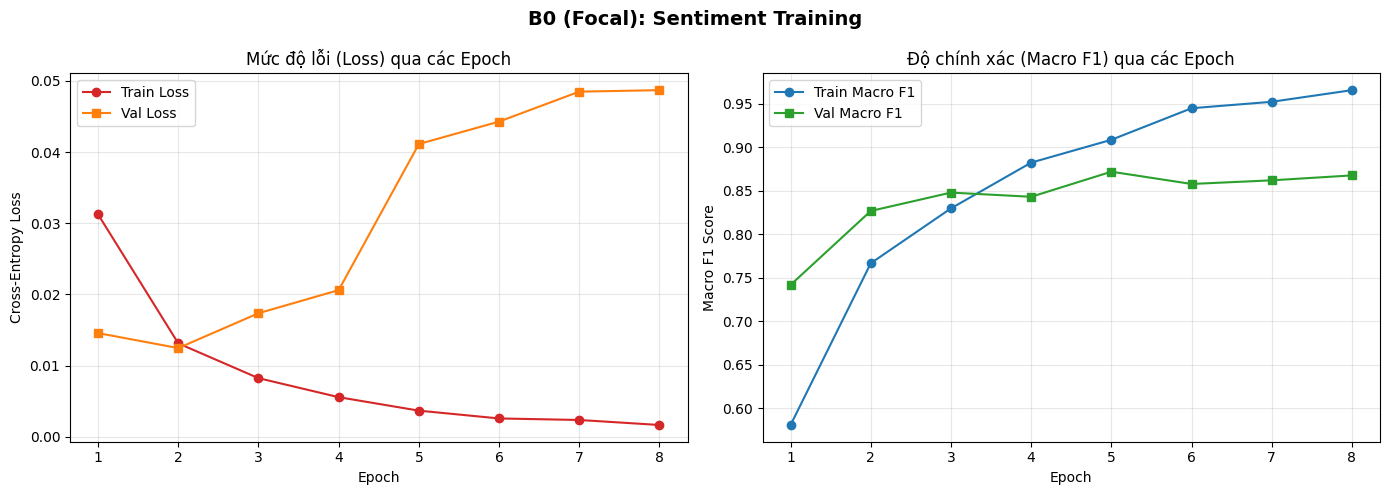


Chẩn đoán validation === B0_Focal_Sent (SENTIMENT) ===
              precision    recall  f1-score   support

    Negative     0.9592    0.9674    0.9633       705
     Neutral     0.7541    0.6301    0.6866        73
    Positive     0.9630    0.9702    0.9666       805

    accuracy                         0.9533      1583
   macro avg     0.8921    0.8559    0.8721      1583
weighted avg     0.9517    0.9533    0.9522      1583


=== B0 (FOCAL) SENTIMENT - OLD TEST ===
              precision    recall  f1-score   support

    Negative     0.9507    0.9709    0.9607      1409
     Neutral     0.7073    0.5210    0.6000       167
    Positive     0.9514    0.9597    0.9555      1590

    accuracy                         0.9416      3166
   macro avg     0.8698    0.8172    0.8387      3166
weighted avg     0.9382    0.9416    0.9391      3166



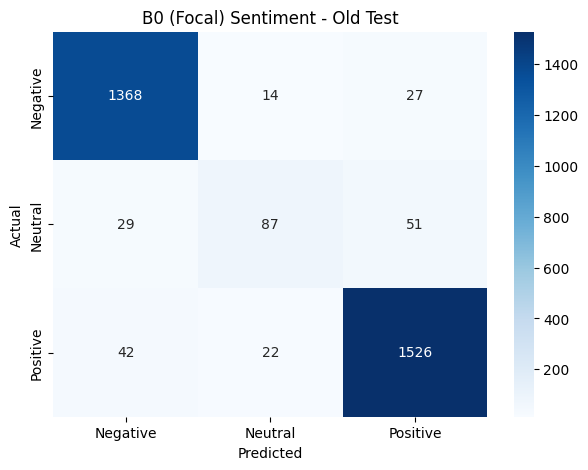


=== B0 (FOCAL) SENTIMENT - NEW TEST ===
              precision    recall  f1-score   support

    Negative     0.9583    0.9836    0.9708      1402
     Neutral     0.7398    0.5759    0.6477       158
    Positive     0.9744    0.9732    0.9738      1606

    accuracy                         0.9580      3166
   macro avg     0.8909    0.8443    0.8641      3166
weighted avg     0.9556    0.9580    0.9562      3166



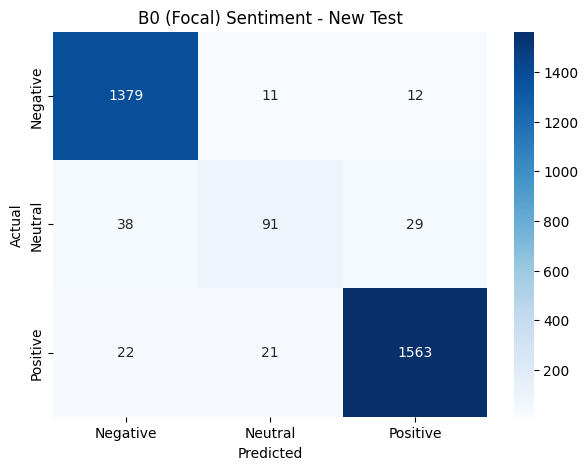

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.0289 | Val Loss: 0.0127 | Train F1: 0.4836 | Val F1: 0.7409
New best (Val F1: 0.7409)
Epoch 02 | Train Loss: 0.0126 | Val Loss: 0.0123 | Train F1: 0.7301 | Val F1: 0.7567
New best (Val F1: 0.7567)
Epoch 03 | Train Loss: 0.0088 | Val Loss: 0.0140 | Train F1: 0.7740 | Val F1: 0.7762
New best (Val F1: 0.7762)
Epoch 04 | Train Loss: 0.0066 | Val Loss: 0.0153 | Train F1: 0.8139 | Val F1: 0.7624
Không cải thiện 1/3
Epoch 05 | Train Loss: 0.0051 | Val Loss: 0.0226 | Train F1: 0.8351 | Val F1: 0.7712
Không cải thiện 2/3
Epoch 06 | Train Loss: 0.0039 | Val Loss: 0.0208 | Train F1: 0.8613 | Val F1: 0.7513
Không cải thiện 3/3
Early stopping tại epoch 6!

Best validation topic Macro F1: 0.7762


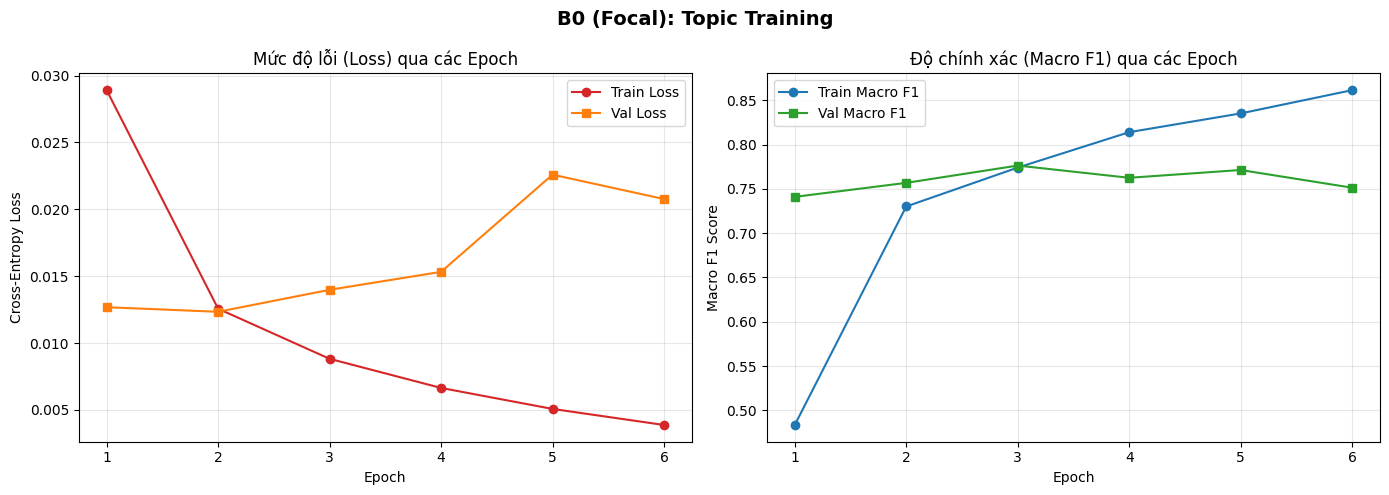


Chẩn đoán validation === B0_Focal_Topic (TOPIC) ===
              precision    recall  f1-score   support

    Lecturer     0.9671    0.8679    0.9148      1151
    Training     0.6628    0.8614    0.7492       267
    Facility     0.8571    0.9429    0.8980        70
      Others     0.4762    0.6316    0.5430        95

    accuracy                         0.8560      1583
   macro avg     0.7408    0.8260    0.7762      1583
weighted avg     0.8814    0.8560    0.8638      1583


=== B0 (FOCAL) TOPIC - OLD TEST ===
              precision    recall  f1-score   support

    Lecturer     0.9655    0.8681    0.9142      2290
    Training     0.6743    0.8287    0.7435       572
    Facility     0.8598    0.9724    0.9126       145
      Others     0.4417    0.6667    0.5313       159

    accuracy                         0.8557      3166
   macro avg     0.7353    0.8340    0.7754      3166
weighted avg     0.8817    0.8557    0.8641      3166



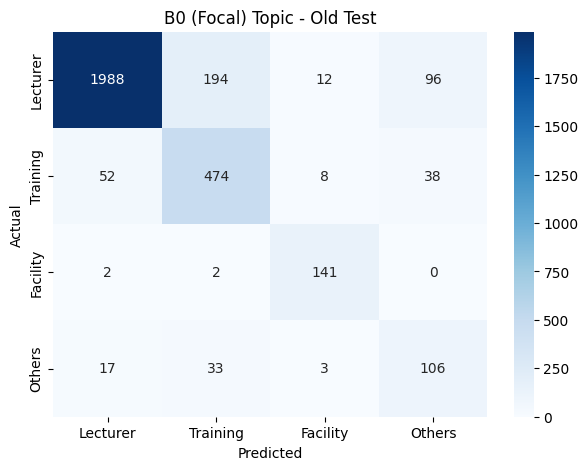


=== B0 (FOCAL) TOPIC - NEW TEST ===
              precision    recall  f1-score   support

    Lecturer     0.9864    0.8857    0.9334      2293
    Training     0.7511    0.8934    0.8161       591
    Facility     0.8841    0.9932    0.9355       146
      Others     0.4667    0.8235    0.5957       136

    accuracy                         0.8895      3166
   macro avg     0.7721    0.8990    0.8202      3166
weighted avg     0.9154    0.8895    0.8971      3166



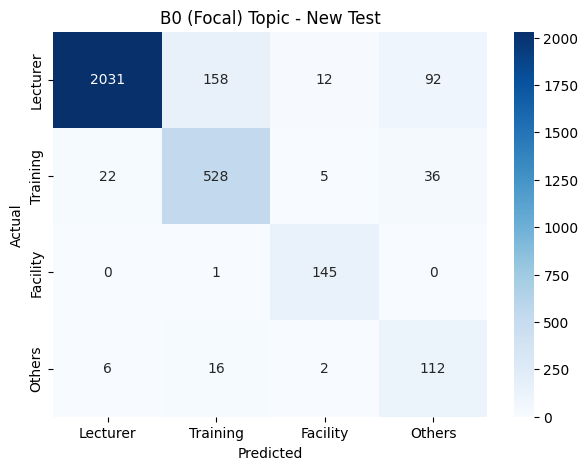


B0 (ASL): Single Task - Asymmetric Loss


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.3893 | Val Loss: 0.1696 | Train F1: 0.6009 | Val F1: 0.7867
New best (Val F1: 0.7867)
Epoch 02 | Train Loss: 0.1421 | Val Loss: 0.1464 | Train F1: 0.8068 | Val F1: 0.8460
New best (Val F1: 0.8460)
Epoch 03 | Train Loss: 0.1043 | Val Loss: 0.1555 | Train F1: 0.8606 | Val F1: 0.8431
Không cải thiện 1/3
Epoch 04 | Train Loss: 0.0828 | Val Loss: 0.1586 | Train F1: 0.9026 | Val F1: 0.8469
New best (Val F1: 0.8469)
Epoch 05 | Train Loss: 0.0643 | Val Loss: 0.1583 | Train F1: 0.9279 | Val F1: 0.8541
New best (Val F1: 0.8541)
Epoch 06 | Train Loss: 0.0539 | Val Loss: 0.1564 | Train F1: 0.9469 | Val F1: 0.8790
New best (Val F1: 0.8790)
Epoch 07 | Train Loss: 0.0437 | Val Loss: 0.1683 | Train F1: 0.9583 | Val F1: 0.8632
Không cải thiện 1/3
Epoch 08 | Train Loss: 0.0365 | Val Loss: 0.1705 | Train F1: 0.9703 | Val F1: 0.8720
Không cải thiện 2/3
Epoch 09 | Train Loss: 0.0313 | Val Loss: 0.1706 | Train F1: 0.9744 | Val F1: 0.8774
Không cải thiện 3/3
Early stopping tại epoch 

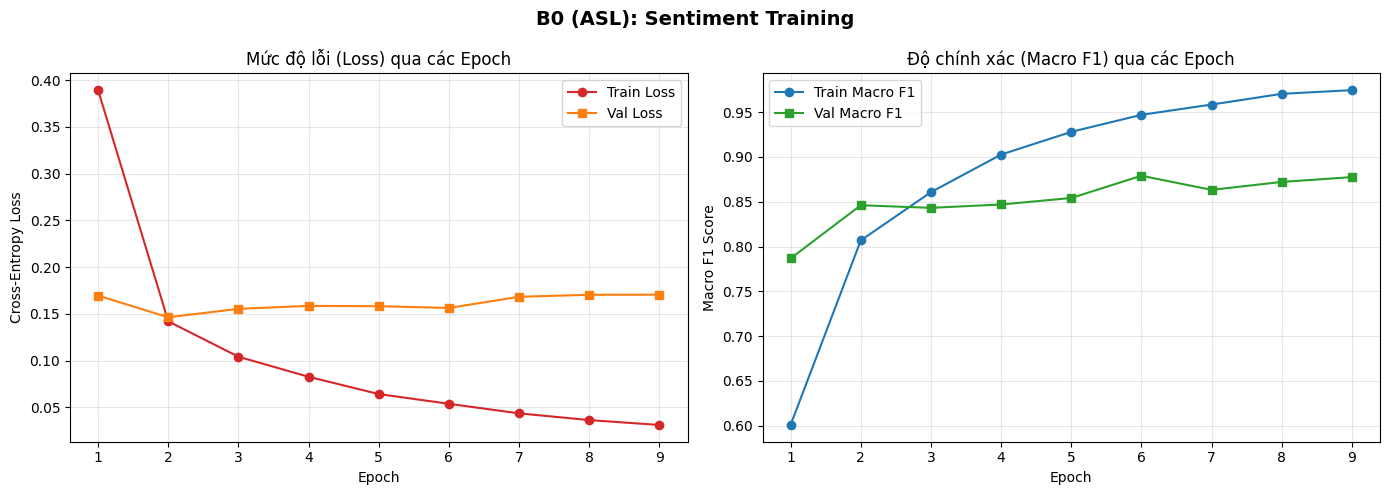


Chẩn đoán validation === B0_ASL_Sent (SENTIMENT) ===
              precision    recall  f1-score   support

    Negative     0.9583    0.9773    0.9677       705
     Neutral     0.7705    0.6438    0.7015        73
    Positive     0.9689    0.9665    0.9677       805

    accuracy                         0.9564      1583
   macro avg     0.8992    0.8625    0.8790      1583
weighted avg     0.9550    0.9564    0.9554      1583


=== B0 (ASL) SENTIMENT - OLD TEST ===
              precision    recall  f1-score   support

    Negative     0.9511    0.9666    0.9588      1409
     Neutral     0.6712    0.5868    0.6262       167
    Positive     0.9597    0.9585    0.9591      1590

    accuracy                         0.9425      3166
   macro avg     0.8607    0.8373    0.8480      3166
weighted avg     0.9407    0.9425    0.9414      3166



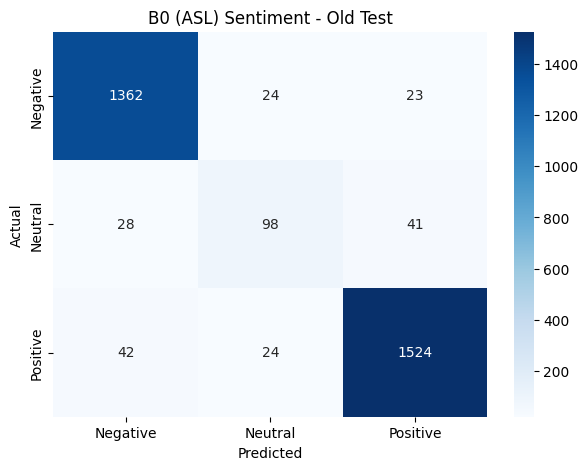


=== B0 (ASL) SENTIMENT - NEW TEST ===
              precision    recall  f1-score   support

    Negative     0.9595    0.9800    0.9697      1402
     Neutral     0.7123    0.6582    0.6842       158
    Positive     0.9836    0.9726    0.9781      1606

    accuracy                         0.9602      3166
   macro avg     0.8852    0.8703    0.8773      3166
weighted avg     0.9594    0.9602    0.9597      3166



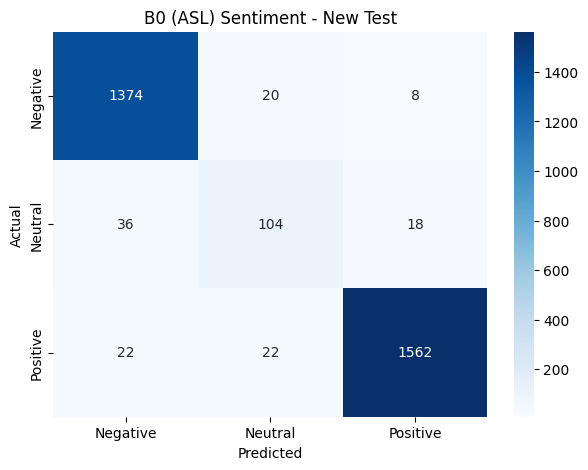

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.5973 | Val Loss: 0.3098 | Train F1: 0.5016 | Val F1: 0.7424
New best (Val F1: 0.7424)
Epoch 02 | Train Loss: 0.2693 | Val Loss: 0.2409 | Train F1: 0.7679 | Val F1: 0.8278
New best (Val F1: 0.8278)
Epoch 03 | Train Loss: 0.2120 | Val Loss: 0.2650 | Train F1: 0.8151 | Val F1: 0.8084
Không cải thiện 1/3
Epoch 04 | Train Loss: 0.1699 | Val Loss: 0.2788 | Train F1: 0.8490 | Val F1: 0.8029
Không cải thiện 2/3
Epoch 05 | Train Loss: 0.1359 | Val Loss: 0.3015 | Train F1: 0.8767 | Val F1: 0.8051
Không cải thiện 3/3
Early stopping tại epoch 5!

Best validation topic Macro F1: 0.8278


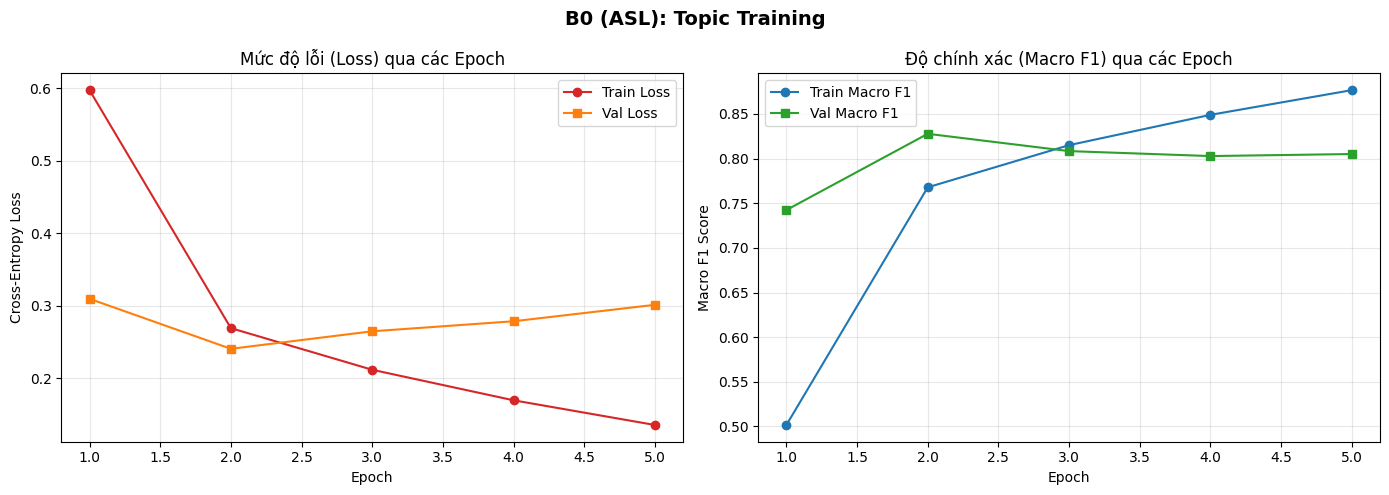


Chẩn đoán validation === B0_ASL_Topic (TOPIC) ===
              precision    recall  f1-score   support

    Lecturer     0.9500    0.9418    0.9459      1151
    Training     0.7986    0.8464    0.8218       267
    Facility     0.9545    0.9000    0.9265        70
      Others     0.6237    0.6105    0.6170        95

    accuracy                         0.9040      1583
   macro avg     0.8317    0.8247    0.8278      1583
weighted avg     0.9051    0.9040    0.9044      1583


=== B0 (ASL) TOPIC - OLD TEST ===
              precision    recall  f1-score   support

    Lecturer     0.9435    0.9332    0.9383      2290
    Training     0.7764    0.7710    0.7737       572
    Facility     0.9565    0.9103    0.9329       145
      Others     0.5026    0.6164    0.5537       159

    accuracy                         0.8869      3166
   macro avg     0.7947    0.8077    0.7996      3166
weighted avg     0.8918    0.8869    0.8890      3166



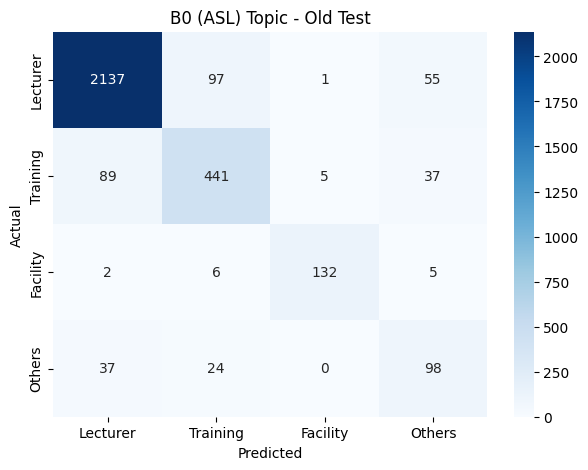


=== B0 (ASL) TOPIC - NEW TEST ===
              precision    recall  f1-score   support

    Lecturer     0.9656    0.9538    0.9596      2293
    Training     0.8697    0.8359    0.8525       591
    Facility     0.9783    0.9247    0.9507       146
      Others     0.5333    0.7647    0.6284       136

    accuracy                         0.9223      3166
   macro avg     0.8367    0.8698    0.8478      3166
weighted avg     0.9297    0.9223    0.9250      3166



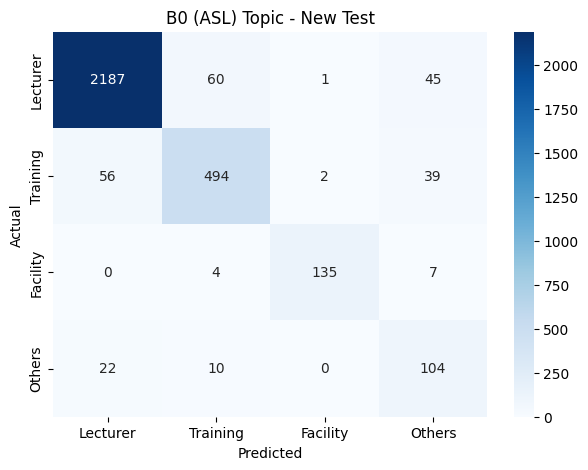

In [ ]:
class BaselineModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME)
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(self.encoder.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))

def train_single_task(model, train_loader, val_loader, loss_fn, task, model_name="b0", patience=3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * WARMUP_RATIO), total_steps)
    
    model.to(DEVICE)
    best_f1, no_improve, history = 0.0, 0, []

    for epoch in range(1, EPOCHS + 1):
        # PHA 1: HUẤN LUYỆN (TRAINING)
        model.train()
        train_loss = 0
        train_preds, train_targets = [], []
        
        for batch in train_loader:
            ids, mask = batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE)
            targets = batch[task].to(DEVICE)
            
            optimizer.zero_grad()
            logits = model(ids, mask)
            loss = loss_fn(logits, targets)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item()
            train_preds.extend(logits.argmax(-1).cpu().tolist())
            train_targets.extend(targets.cpu().tolist())

        # Tính toán chỉ số Train
        train_loss = train_loss / len(train_loader)
        train_acc = accuracy_score(train_targets, train_preds)
        train_f1 = f1_score(train_targets, train_preds, average="macro")

        # PHA 2: KIỂM CHỨNG (VALIDATION)
        model.eval()
        val_loss = 0
        val_preds, val_targets = [], []
        
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE)
                mask = batch["attention_mask"].to(DEVICE)
                targets = batch[task].to(DEVICE) # <-- Cần lấy targets để tính val_loss
                
                logits = model(ids, mask)
                loss = loss_fn(logits, targets)
                
                val_loss += loss.item()
                val_preds.extend(logits.argmax(-1).cpu().tolist())
                val_targets.extend(targets.cpu().tolist())

        # Tính toán chỉ số Validation
        val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(val_targets, val_preds)
        val_f1 = f1_score(val_targets, val_preds, average="macro")
        
        # PHA 3: LƯU LỊCH SỬ VÀ IN KẾT QUẢ
        history.append({
            "epoch": epoch, 
            "train_loss": train_loss, "val_loss": val_loss,
            # "train_acc": train_acc, "val_acc": val_acc,
            "train_f1": train_f1, "val_f1": val_f1
        })
        
        # Format chuỗi in ra y hệt yêu cầu của bạn
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")

        # Early Stopping dựa trên Val F1
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
            print(f"New best (Val F1: {best_f1:.4f})")
        else:
            no_improve += 1
            print(f"Không cải thiện {no_improve}/{patience}")
            if no_improve >= patience:
                print(f"Early stopping tại epoch {epoch}!")
                break

    # Load lại weights tốt nhất trước khi trả về
    model.load_state_dict(best_state)
    torch.save(best_state, f"{model_name}_best.pt")
    print(f"\nBest validation {task} Macro F1: {best_f1:.4f}")
    
    return model, pd.DataFrame(history), best_f1

# Khởi tạo các hàm loss
ce_sent  = nn.CrossEntropyLoss()
ce_topic = nn.CrossEntropyLoss()

wce_sent  = nn.CrossEntropyLoss(weight=sent_weights.to(DEVICE))
wce_topic = nn.CrossEntropyLoss(weight=topic_weights.to(DEVICE))

focal_sent  = FocalLoss(alpha=sent_focal_alpha,  gamma=2.0).to(DEVICE)
focal_topic = FocalLoss(alpha=topic_focal_alpha, gamma=3.0).to(DEVICE)

asl_sent = ClassSpecificAsymmetricLoss(
    gamma_neg_list=[0.0, 4.0, 0.0],  
    gamma_pos_list=[2.0, 1.0, 2.0]   
).to(DEVICE)

asl_topic = ClassSpecificAsymmetricLoss(
    gamma_neg_list=[0.0, 0.0, 0.0, 4.0], 
    gamma_pos_list=[2.0, 2.0, 2.0, 1.0]
).to(DEVICE)

# CHẠY THỰC NGHIỆM B0 - SINGLE TASK LEARNING (ĐỘC LẬP TỪNG TASK)
results_old_test_stl = {}
results_new_test_stl = {}

# HÀM BỔ TRỢ: Lấy F1 Macro từ Dictionary Report để nhét vào bảng
def get_macro_f1_from_report(report_dict):
    return report_dict["macro avg"]["f1-score"]


# ── 1. B0 (CE): Standard Cross Entropy ──
print("\n" + "="*50)
print("B0 (CE): Single Task - Standard Cross Entropy")
print("="*50)
# >> Sentiment
model_b0_ce_sent = BaselineModel(num_classes=NUM_SENTIMENT).to(DEVICE)
model_b0_ce_sent, hist_b0_ce_sent, _ = train_single_task(model_b0_ce_sent, train_loader, val_loader, 
                                                         ce_sent, task="sentiment", model_name="B0_CE_Sent")
plot_training_history(hist_b0_ce_sent, title="B0 (CE): Sentiment Training")
diagnose_validation_single_task(model_b0_ce_sent, val_loader, "B0_CE_Sent", task="sentiment")
rep_sent_old_ce = evaluate_and_plot(model_b0_ce_sent, test_loader, "sentiment", SENT_NAMES, "B0 (CE) Sentiment - Old Test")
rep_sent_new_ce = evaluate_and_plot(model_b0_ce_sent, test_loader1, "sentiment", SENT_NAMES, "B0 (CE) Sentiment - New Test")

# >> Topic
model_b0_ce_topic = BaselineModel(num_classes=NUM_TOPIC).to(DEVICE)
model_b0_ce_topic, hist_b0_ce_topic, _ = train_single_task(model_b0_ce_topic, train_loader, val_loader, 
                                                           ce_topic, task="topic", model_name="B0_CE_Topic")
plot_training_history(hist_b0_ce_topic, title="B0 (CE): Topic Training")
diagnose_validation_single_task(model_b0_ce_topic, val_loader, "B0_CE_Topic", task="topic")
rep_topic_old_ce = evaluate_and_plot(model_b0_ce_topic, test_loader, "topic", TOPIC_NAMES, "B0 (CE) Topic - Old Test")
rep_topic_new_ce = evaluate_and_plot(model_b0_ce_topic, test_loader1, "topic", TOPIC_NAMES, "B0 (CE) Topic - New Test")

# >> Đóng gói kết quả (Giả lập cấu trúc MTL để in bảng)
results_old_test_stl["B0_CE"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_old_ce),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_old_ce),
    "sent_report": rep_sent_old_ce,
    "topic_report": rep_topic_old_ce
}
results_new_test_stl["B0_CE"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_new_ce),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_new_ce),
    "sent_report": rep_sent_new_ce,
    "topic_report": rep_topic_new_ce
}


# ── 2. B0 (WCE): Weighted Cross Entropy ──
print("\n" + "="*50)
print("B0 (WCE): Single Task - Weighted Cross Entropy")
print("="*50)
# >> Sentiment
model_b0_wce_sent = BaselineModel(num_classes=NUM_SENTIMENT).to(DEVICE)
model_b0_wce_sent, hist_b0_wce_sent, _ = train_single_task(model_b0_wce_sent, train_loader, val_loader, 
                                                           wce_sent, task="sentiment", model_name="B0_WCE_Sent")
plot_training_history(hist_b0_wce_sent, title="B0 (WCE): Sentiment Training")
diagnose_validation_single_task(model_b0_wce_sent, val_loader, "B0_WCE_Sent", task="sentiment")
rep_sent_old_wce = evaluate_and_plot(model_b0_wce_sent, test_loader, "sentiment", SENT_NAMES, "B0 (WCE) Sentiment - Old Test")
rep_sent_new_wce = evaluate_and_plot(model_b0_wce_sent, test_loader1, "sentiment", SENT_NAMES, "B0 (WCE) Sentiment - New Test")

# >> Topic
model_b0_wce_topic = BaselineModel(num_classes=NUM_TOPIC).to(DEVICE)
model_b0_wce_topic, hist_b0_wce_topic, _ = train_single_task(model_b0_wce_topic, train_loader, val_loader, 
                                                             wce_topic, task="topic", model_name="B0_WCE_Topic")
plot_training_history(hist_b0_wce_topic, title="B0 (WCE): Topic Training")
diagnose_validation_single_task(model_b0_wce_topic, val_loader, "B0_WCE_Topic", task="topic")
rep_topic_old_wce = evaluate_and_plot(model_b0_wce_topic, test_loader, "topic", TOPIC_NAMES, "B0 (WCE) Topic - Old Test")
rep_topic_new_wce = evaluate_and_plot(model_b0_wce_topic, test_loader1, "topic", TOPIC_NAMES, "B0 (WCE) Topic - New Test")

results_old_test_stl["B0_WCE"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_old_wce),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_old_wce),
    "sent_report": rep_sent_old_wce,
    "topic_report": rep_topic_old_wce
}
results_new_test_stl["B0_WCE"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_new_wce),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_new_wce),
    "sent_report": rep_sent_new_wce,
    "topic_report": rep_topic_new_wce
}


# ── 3. B0 (Focal): Focal Loss ──
print("\n" + "="*50)
print("B0 (Focal): Single Task - Focal Loss")
print("="*50)
# >> Sentiment
model_b0_focal_sent = BaselineModel(num_classes=NUM_SENTIMENT).to(DEVICE)
model_b0_focal_sent, hist_b0_focal_sent, _ = train_single_task(model_b0_focal_sent, train_loader, val_loader, 
                                                               focal_sent, task="sentiment", model_name="B0_Focal_Sent")
plot_training_history(hist_b0_focal_sent, title="B0 (Focal): Sentiment Training")
diagnose_validation_single_task(model_b0_focal_sent, val_loader, "B0_Focal_Sent", task="sentiment")
rep_sent_old_focal = evaluate_and_plot(model_b0_focal_sent, test_loader, "sentiment", SENT_NAMES, "B0 (Focal) Sentiment - Old Test")
rep_sent_new_focal = evaluate_and_plot(model_b0_focal_sent, test_loader1, "sentiment", SENT_NAMES, "B0 (Focal) Sentiment - New Test")

# >> Topic
model_b0_focal_topic = BaselineModel(num_classes=NUM_TOPIC).to(DEVICE)
model_b0_focal_topic, hist_b0_focal_topic, _ = train_single_task(model_b0_focal_topic, train_loader, val_loader, 
                                                                 focal_topic, task="topic", model_name="B0_Focal_Topic")
plot_training_history(hist_b0_focal_topic, title="B0 (Focal): Topic Training")
diagnose_validation_single_task(model_b0_focal_topic, val_loader, "B0_Focal_Topic", task="topic")
rep_topic_old_focal = evaluate_and_plot(model_b0_focal_topic, test_loader, "topic", TOPIC_NAMES, "B0 (Focal) Topic - Old Test")
rep_topic_new_focal = evaluate_and_plot(model_b0_focal_topic, test_loader1, "topic", TOPIC_NAMES, "B0 (Focal) Topic - New Test")

results_old_test_stl["B0_Focal"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_old_focal),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_old_focal),
    "sent_report": rep_sent_old_focal,
    "topic_report": rep_topic_old_focal
}
results_new_test_stl["B0_Focal"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_new_focal),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_new_focal),
    "sent_report": rep_sent_new_focal,
    "topic_report": rep_topic_new_focal
}


# ── 4. B0 (ASL): Asymmetric Loss ──
print("\n" + "="*50)
print("B0 (ASL): Single Task - Asymmetric Loss")
print("="*50)
# >> Sentiment
model_b0_asl_sent = BaselineModel(num_classes=NUM_SENTIMENT).to(DEVICE)
model_b0_asl_sent, hist_b0_asl_sent, _ = train_single_task(model_b0_asl_sent, train_loader, val_loader, 
                                                           asl_sent, task="sentiment", model_name="B0_ASL_Sent")
plot_training_history(hist_b0_asl_sent, title="B0 (ASL): Sentiment Training")
diagnose_validation_single_task(model_b0_asl_sent, val_loader, "B0_ASL_Sent", task="sentiment")
rep_sent_old_asl = evaluate_and_plot(model_b0_asl_sent, test_loader, "sentiment", SENT_NAMES, "B0 (ASL) Sentiment - Old Test")
rep_sent_new_asl = evaluate_and_plot(model_b0_asl_sent, test_loader1, "sentiment", SENT_NAMES, "B0 (ASL) Sentiment - New Test")

# >> Topic
model_b0_asl_topic = BaselineModel(num_classes=NUM_TOPIC).to(DEVICE)
model_b0_asl_topic, hist_b0_asl_topic, _ = train_single_task(model_b0_asl_topic, train_loader, val_loader, 
                                                             asl_topic, task="topic", model_name="B0_ASL_Topic")
plot_training_history(hist_b0_asl_topic, title="B0 (ASL): Topic Training")
diagnose_validation_single_task(model_b0_asl_topic, val_loader, "B0_ASL_Topic", task="topic")
rep_topic_old_asl = evaluate_and_plot(model_b0_asl_topic, test_loader, "topic", TOPIC_NAMES, "B0 (ASL) Topic - Old Test")
rep_topic_new_asl = evaluate_and_plot(model_b0_asl_topic, test_loader1, "topic", TOPIC_NAMES, "B0 (ASL) Topic - New Test")

results_old_test_stl["B0_ASL"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_old_asl),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_old_asl),
    "sent_report": rep_sent_old_asl,
    "topic_report": rep_topic_old_asl
}
results_new_test_stl["B0_ASL"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_new_asl),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_new_asl),
    "sent_report": rep_sent_new_asl,
    "topic_report": rep_topic_new_asl
}